##  __Section 1 - Machine Learning__

### __Splitting the Dataset__
In this code block, I imported the relevant libraries and functions- such as `numpy, pandas, matplotlib and sklearn`- that are necessary. <br>
Using panda to load the CSV dataset, I split it into subsets for training data (0.8) and testing data (0.2), as this needs to be used later on during the regression.

In [126]:
import pandas as panda
from pandas import DataFrame
import matplotlib.pyplot as plot
import numpy as numpy
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# creating a dataframe from the nutrients dataset
df = panda.read_csv('dataset/e1_nutrients.csv')

#split the large dataset into training and test datasets
training_data_df, test_data_df = train_test_split(df, test_size=0.2, random_state=42)

filtered_training_df = training_data_df.copy()
original_df_copy = df.copy()

### __Data Preparation - Cleaning the data__
The first step before predicting new points of Nitrite is to clean the data, and this means removing the outliers. <br>
To do this, I passing the training dataset for the filtering, and retreiving all the values within the 'Depth' column. <br>
Whilst looking at the dataset, I saw that the values of depth had been repeated, i.e. 0-60, 0-60, which is why I used `.unique()` whilst iterating through the depth values.<br>
Because I wanted all the values corresponding to the current depth in the iteration, I used .copy() to copy the numbers separately. <br>
Creating an array of the chemicals from the dataset allowed me to iterate through them AND the depth one at a time, so that I could better focus on the sets of values within the dataset. I did include NITRITE in the chemical list in the beginning but I then realised I was not supposed to, because that was my target. <br><br>
To calculate the outliers, I first used numpy's `quantile` to know the lower and upper quartile, so that I could calculate the interquartile range. Using these numbers, I found the higher and lower bounds, and I use these to check that the value is within the range. If it isn't I set these to `None` discard them via `.dropna()`.

In [127]:
# get all values witihin the column depth from the dataframe
depth_values = filtered_training_df['Depth']
    
# because values in the depth column are repeated, i.e. numbers 0-60 are repeated multiple times, filter out the repeated values and get only the unique values, using .unique()
for depth in depth_values.unique():
    # because we currently have all values for the depth column, we want to narrow our focus to only values for the current depth 
    # so we copy the dataframe and filter it to only include the rows where the depth value is equal to the current depth value we are iterating over
    current_depth_values = filtered_training_df.loc[depth_values == depth].copy()
        
    # we want to get values for each chemical given a depth val
    # so we create a list of chemicals fromt he nutrients dataset we want to loop through, excluding NITRITE
    chemical_list = ['NITRATE+NITRITE', 'AMMONIA', 'SILICATE', 'PHOSPHATE']
    for chemical in chemical_list:
            
    # for each chemical, we want to get the values for that chemical at the current depth value we are iterating over
        depth_chemical_values = current_depth_values[chemical]
            
        # to remove the outliers, we have to caluclate the interquartile range IQR by finding the upper quartile Q3 and lower quartile Q1
        # numpy has a built-in function quantile-- the value 0.75 gives the upper range and 0.25 gives the lower range
        Q3 = depth_chemical_values.quantile(0.75)
        Q1 = depth_chemical_values.quantile(0.25)
            
        # subtracting the bigger quartile from the smaller quartile
        IQR = Q3 - Q1
            
        # we have to calculate higher bound and lower bound using the quaritiles and IQR
        higher_bound = Q3 + 1.5 * IQR
        lower_bound = Q1 - 1.5 * IQR
            
        for index, value in enumerate(depth_chemical_values):
            if value > higher_bound or value < lower_bound:
                depth_chemical_values.iloc[index] = None
            
            current_depth_values[chemical] = depth_chemical_values
        filtered_training_df.loc[depth_values == depth] = current_depth_values
cleaned_trained_df = filtered_training_df.dropna()

### __Scaling__
After cleaning the training data above, I realised the next step needed was scaling. I learnt I had to do this because the regessors I was using, particularly the `MLPRegressor` for Neural Network and `LinearRegressor` for Linear Regression, were partial to big numbers without even knowing the context behind them. Without the context, the models would not be able to predict fairly and accurately, but since we are not providing the context behind the dataset, I had to simply scale the training dataset. <br><br>
To do this, I chose to use `RobustScaler`, because in my research for the types of scalers to use, I saw that `RobustScaler` actually scales uses the interquartile range.<br>
I created 2 scalers-- one for all columns excluding NITRITE, and one for NITRITE, the target, only. These saclers were fit onto the *training* data using `.fit_transform()` only, not on the test data because we should avoid data leakage.

In [128]:
# scaling the data 
x_scaler = RobustScaler()
y_scaler = RobustScaler()
x_train = x_scaler.fit_transform(cleaned_trained_df.drop(columns=['NITRITE'])) # all but NITRITE
y_train = y_scaler.fit_transform(cleaned_trained_df[['NITRITE']]).ravel() # target (NITRITE)

# scaling test data
x_test = x_scaler.transform(test_data_df.drop(columns=['NITRITE']))
y_test = y_scaler.transform(test_data_df[['NITRITE']]).ravel()

filtered_df = filtered_training_df
scaled_df = cleaned_trained_df.copy().astype(float)
scale_columns = scaled_df.columns != "NITRITE"
scaled_df.loc[:, scale_columns] = x_train

### __Plotting graphs for visualisation__
I needed to visualise the results of the scaling and the cleaning of the training data, so to do this I chose to plot each chemical from the list against Depth in a scatter graph. At first, the scaled data was overlapping the original and cleaned which was making it difficult to distinguish and understand, so I had to adjust my axes.<BR>
From the graphs below, I can see that whilst comparing the 'cleaned' data against the original, uncleaned copy, the erroneous numbers were removed properly.

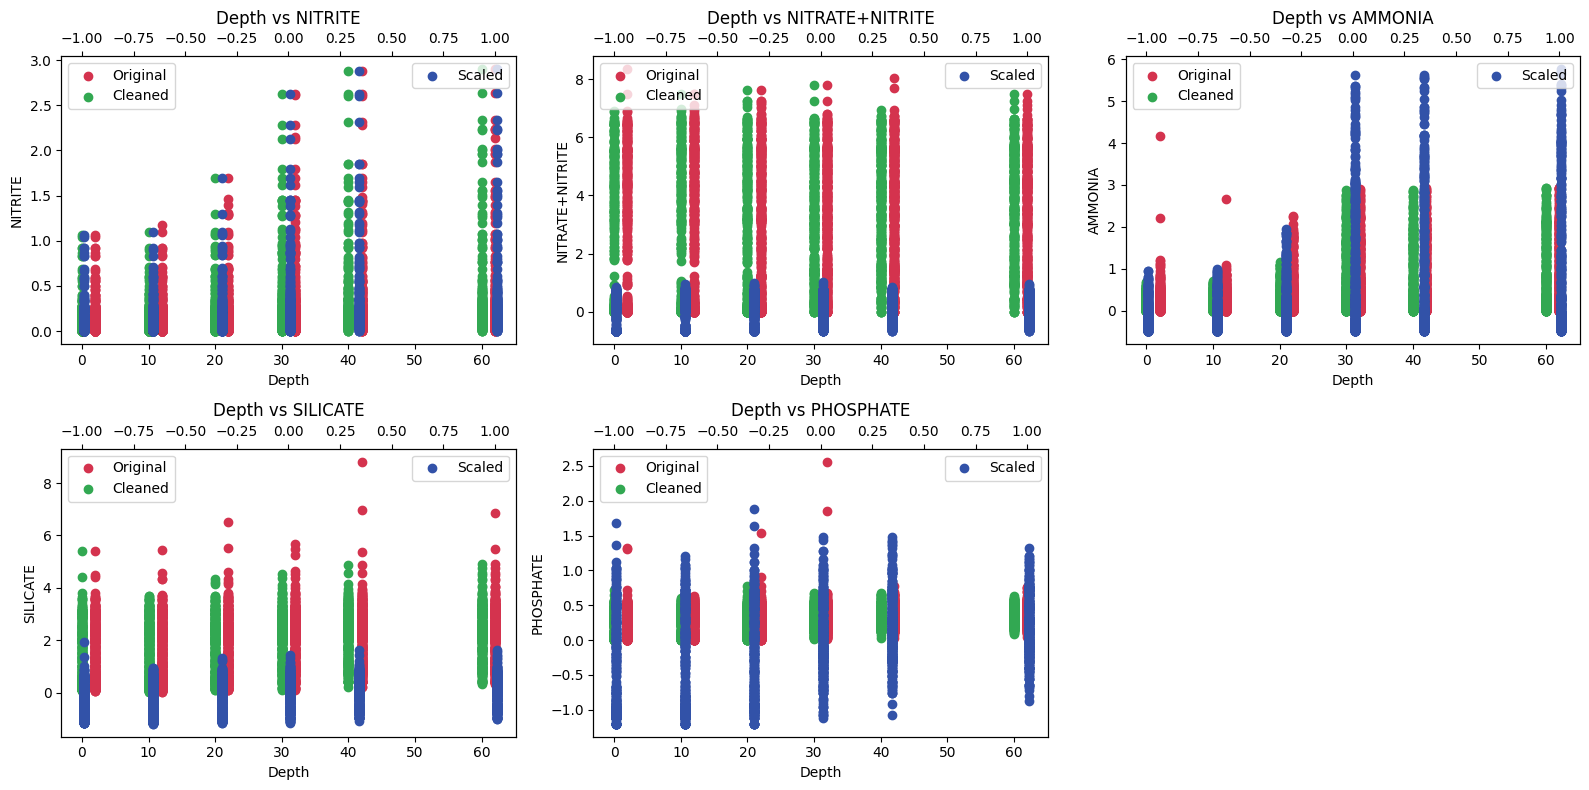

In [129]:
# scatter graphs to visualise the original data against the cleaned and scaled data
chemical_list = ['NITRITE', 'NITRATE+NITRITE', 'AMMONIA', 'SILICATE', 'PHOSPHATE']
    
fig, axes = plot.subplots(2, 3, figsize=(16, 8), sharex=False)
axes = axes.flatten()

for ax, chemical in zip(axes, chemical_list):
    ax.scatter(
        original_df_copy['Depth'] +2.0,
        original_df_copy[chemical],
        color='#d4334e',
        label='Original'
            
    )
    ax.scatter(
        cleaned_trained_df['Depth'],
        cleaned_trained_df[chemical],
        label='Cleaned',
        color='#32a852'
            
    )
    
    ax2 = ax.twiny()
    ax2.set_xlim(-1.1, 1.1)
        
    ax2.scatter(
        scaled_df['Depth']+0.01,
        scaled_df[chemical],
        label='Scaled',
        color='#3252a8'
    )

    ax.set_title(f'Depth vs {chemical}')
    ax.set_xlabel('Depth')
    ax.set_ylabel(chemical)
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
    
for ax in axes[len(chemical_list):]:
    ax.remove()
        
plot.tight_layout()
plot.show()

### __Building regressors.__ <br>
#### Linear Regressor
To build the linear regressor, I used the `sklearn` library from the lab sheets and cheatsheets on the DLE. 
I fit the x_train and y_train onto the regressor to train the model, so it can then make predictions on the training data and the testing data. The reason for this is so that I could evaluate the model's performance with dat that is unseen. For the evaluation, I used `sklearn.metrics` to obtain the mean squared error for both predictions. <br><br>

In [130]:
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
   
linear_regression_model = LinearRegression()
random_forest_model = RandomForestRegressor(random_state=42)
neural_network_model = MLPRegressor(random_state=42, max_iter=2500)


"""Linear regression."""
# linear regression fit to the training data and making predictions on both the training and test data
linear = linear_regression_model.fit(x_train, y_train)
linear_train_prediction = linear.predict(x_train)
linear_test_prediction = linear.predict(x_test)
      
# linear training score
train_linear_mse = mean_squared_error(y_train, linear_train_prediction)
test_linear_mse = mean_squared_error(y_test, linear_test_prediction)

#### Random Forest Regression.
The same steps were applied to the random forest regression- fit the train data onto the model, get predictions, get mean squred error scores for each prediction. However, I learned that tuning the random forest model was ideal, becasue it would help the model learn better patterns as well as avoid overfitting. <br>
In order to do this, I looked into hyperparameter tuning and the two the most prominent methods I found for this used GridSearchCV and RandomisedSearchCV. Because GridSearchCV uses all possible combinations of the hyperparameter values, it is exhaustive and very time consuming especially wiht large datasets, which the e1_nutrients is. Therefore, I opted to use RandomisedSearchCV instead. A range of values were defined for each hyperparameter, i.e. `n_estimators`, `max_depth`, `max_features` etc in a distribution dictionary which was passed as a parameter itself into RandomisedSearchCV, and the best parameters were found: `best_rf_params = random_search.best_params_`. After plugging the best parameters into the random forest model, I carried out the same steps as before. <br>
When trying to find the best parameters, I initially kept a small range of values for the number of estimators, but I found that even though the search time was relatively quick, there was little to no improvement bewteen the results of the tuned vs untuned model. So I adjusted this to include more values-- this resulted in more time being consumed executing this, and though the train and test MSE scores had reduced, the change was not signifcant enough.

In [131]:
"""Random forest regression."""
# fitting the random forest model to the training data and making predictions on both the training and test data
rf = random_forest_model.fit(x_train, y_train)
random_forest_train_prediction = rf.predict(x_train)
random_forest_test_prediction = rf.predict(x_test)

# random forest training score
random_forest_train_mse = mean_squared_error(y_train, random_forest_train_prediction)
random_forest_test_mse = mean_squared_error(y_test, random_forest_test_prediction)

In [132]:
""""Obtaining the best hyperparameters for the random forest model using RandomizedSearchCV."""

from sklearn.model_selection import RandomizedSearchCV

untuned_rf = RandomForestRegressor(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_features': ['sqrt', 'log2', None, 0.5, 0.75],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(untuned_rf, param_distributions=param_dist, n_iter=150, cv=5, n_jobs=-1, scoring='neg_mean_squared_error', return_train_score=True)
random_search.fit(x_train, y_train)
best_rf_params = random_search.best_params_
print("Best hyperparameters for Random Forest:", best_rf_params)

Best hyperparameters for Random Forest: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30, 'bootstrap': False}


In [133]:
"""Fitting the tuned random forest model with the best hyperparameters."""
from sklearn.ensemble import RandomForestRegressor

tuned_rf = RandomForestRegressor(**best_rf_params, random_state=42)
tuned_rf.fit(x_train, y_train)

tuned_rf_train_prediction = tuned_rf.predict(x_train)
tuned_rf_test_prediction = tuned_rf.predict(x_test)

# training score for tuned rf 
tuned_rf_train_mse = mean_squared_error(y_train, tuned_rf_train_prediction)
tuned_rf_test_mse = mean_squared_error(y_test, tuned_rf_test_prediction)

#### Neural Network Rgression
Similar to Random Forest, I executed additional tuning to the MLP regressor by using RandomisedSearchCV to tune the hyperparameters. Initially, I set the `activation` to `relu` only, and `solver` to `adam`, as generally the default was relu and from my research with GeeksforGeeks I thought the Adam solver was more smart and balanced compared to identity and tanh. However limiting the parameter distribution was not producing a distinguishable difference in the MSE scores. Additionally, I had set my hidden_layer_sizes to be (50,50). This was too low, because it effectively meant that there were only 2 hidden layers with 50 neurons each, and its low value was hindering the MLP model' ability to learn the relationships, hence I increased this to [(100,50), (50,50)].<br>
The best parameters obtained were then used in the model.

In [134]:
"""Neural Network regression (NOT TUNED)."""
# fitting the neural network model to the training data and making predictions on both the training and test data
neural = neural_network_model.fit(x_train, y_train)
neural_network_train_prediction = neural.predict(x_train)
neural_network_test_prediction = neural.predict(x_test)

# training score for neural network
neural_network_train_mse = mean_squared_error(y_train, neural_network_train_prediction)
neural_network_test_mse = mean_squared_error(y_test, neural_network_test_prediction)

In [135]:
"""Obtaining the best parameters for the tuned neural network model by using RandomisedSearchV."""

untuned_nn = MLPRegressor(random_state=42, max_iter=2500)
nn_param_dist = {
    'hidden_layer_sizes': [(100, 50), (50, 50)],
    'activation': ['identity', 'relu', 'tanh'],
    'solver': ['adam', 'sgd', 'lbfgs'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive']
}

nn_random_search = RandomizedSearchCV(
    untuned_nn, 
    param_distributions=nn_param_dist, 
    n_iter=150, 
    cv=5, 
    n_jobs=-1, 
    scoring='neg_mean_squared_error', 
    return_train_score=True
)
nn_random_search.fit(x_train, y_train)
best_nn_params = nn_random_search.best_params_
print("Best hyperparameters for Neural Network:", best_nn_params)

c:\Users\khyat\Documents\2002 70%\venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 108 is smaller than n_iter=150. Running 108 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best hyperparameters for Neural Network: {'solver': 'sgd', 'learning_rate': 'adaptive', 'hidden_layer_sizes': (50, 50), 'alpha': 0.01, 'activation': 'relu'}


In [136]:
"""TUNED neural network regression."""
tuned_nn_model = MLPRegressor(**best_nn_params, random_state=42, max_iter=2500)
tuned_nn_model.fit(x_train, y_train)
tuned_nn_train_prediction = tuned_nn_model.predict(x_train)
tuned_nn_test_prediction = tuned_nn_model.predict(x_test)

# training score for tuned neural network
tuned_nn_train_mse = mean_squared_error(y_train, tuned_nn_train_prediction)
tuned_nn_test_mse = mean_squared_error(y_test, tuned_nn_test_prediction)

In [137]:
# cross validation for all models of regression
linear_cross_val = cross_val_score(linear_regression_model, x_train, y_train, cv=5, scoring='neg_mean_squared_error')
untuned_rf_cross_val = cross_val_score(random_forest_model, x_train, y_train, cv=5, scoring='neg_mean_squared_error')
tuned_rf_cross_val = cross_val_score(tuned_rf, x_train, y_train, cv=5, scoring='neg_mean_squared_error')
nn_cross_val = cross_val_score(neural_network_model, x_train, y_train, cv=5, scoring='neg_mean_squared_error')
tuned_nn_cross_val = cross_val_score(tuned_nn_model, x_train, y_train, cv=5, scoring='neg_mean_squared_error')

# create a dictionary to organise the values to their respective model names for the panda DataFrame
scores_data = {
    'model name': ["Linear Regression", "Random Forest Regression",  "Tuned Random Forest Regression", "Neural Network Regression", "Tuned Neural Network Regression"],
    'cross_value_mean': [linear_cross_val.mean(), untuned_rf_cross_val.mean(), tuned_rf_cross_val.mean(), nn_cross_val.mean(), tuned_nn_cross_val.mean()],
    'train_mse': [train_linear_mse, random_forest_train_mse, tuned_rf_train_mse, neural_network_train_mse, tuned_nn_train_mse],
    'test_mse': [test_linear_mse, random_forest_test_mse, tuned_rf_test_mse, neural_network_test_mse, tuned_nn_test_mse],
    'cross_value_std': [linear_cross_val.std(), untuned_rf_cross_val.std(), tuned_rf_cross_val.std(), nn_cross_val.std(), tuned_nn_cross_val.std()]
}

panda.DataFrame(scores_data).sort_values(by='test_mse')

,model name,cross_value_mean,train_mse,test_mse,cross_value_std
2,Tuned Random Forest Regression,-1.560707,0.078329,1.241401,0.186085
1,Random Forest Regression,-1.669358,0.204948,1.302411,0.177763
4,Tuned Neural Network Regression,-1.924233,1.501526,1.803311,0.146323
3,Neural Network Regression,-1.905816,1.667608,1.815494,0.124032
0,Linear Regression,-2.672020,2.660041,2.492813,0.326600


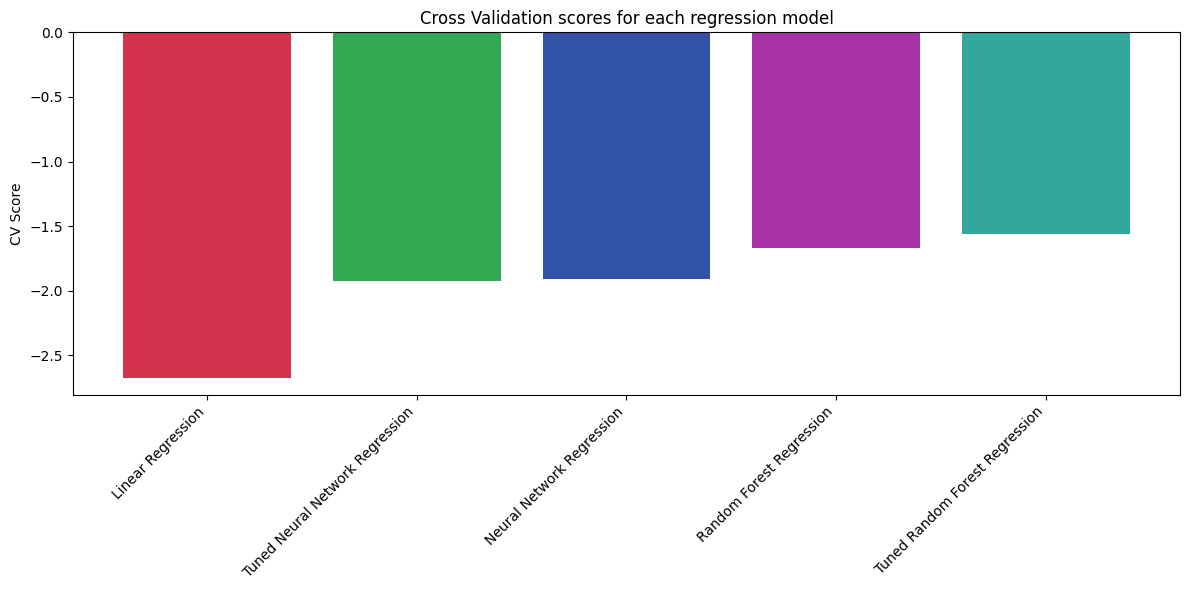

In [ ]:
import pandas as panda
scores_df = panda.DataFrame(scores_data).sort_values(by='cross_value_mean')
plot.figure(figsize=(12, 6))
plot.bar(scores_df['model name'], scores_df['cross_value_mean'], color=['#d4334e', '#32a852', '#3252a8', '#a832a8', '#32a89c'])
plot.ylabel('CV Score')
plot.title('Cross Validation scores for each regression model')
plot.xticks(rotation=45, ha='right')
plot.tight_layout() 
plot.show()

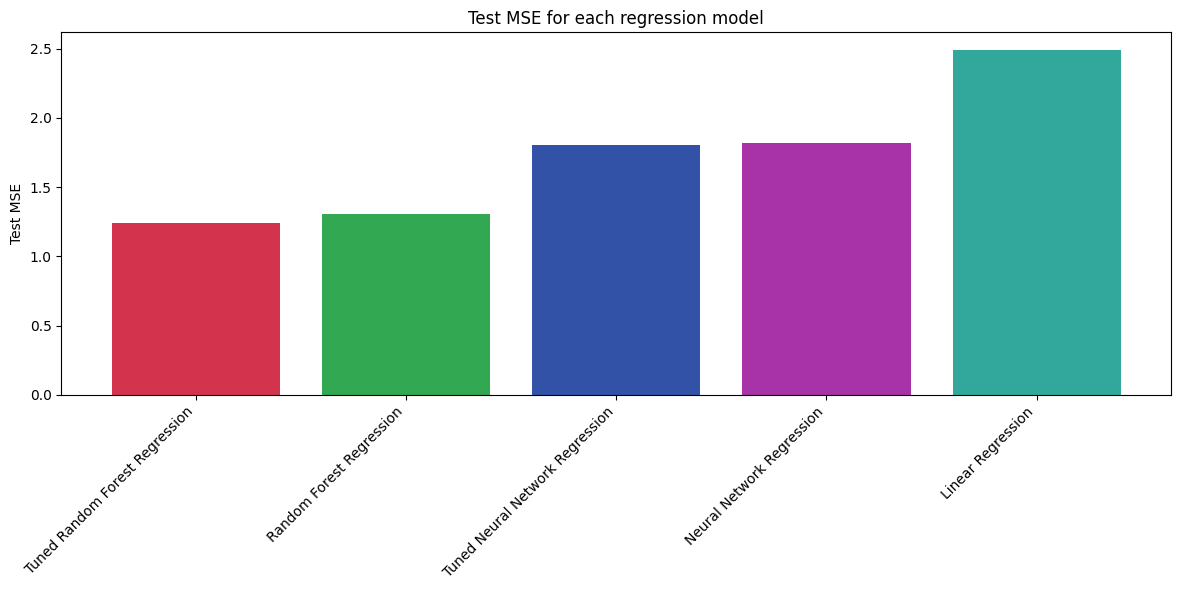

In [142]:
import pandas as panda
scores_df = panda.DataFrame(scores_data).sort_values(by='test_mse')
plot.figure(figsize=(12, 6))
plot.bar(scores_df['model name'], scores_df['test_mse'], color=['#d4334e', '#32a852', '#3252a8', '#a832a8', '#32a89c'])
plot.ylabel('Test MSE')
plot.title('Test MSE for each regression model')
plot.xticks(rotation=45, ha='right')
plot.tight_layout()
plot.show()

#### Mean Square Error and Cross Validation Scores.
It was important to calculate the mean squared error for each prediction on the test and training data done by each regressor to evaluate the accuracy of the predictions. Cross validation was performed and it splits the the data into 5 sections ( `cv=5`), training the model on 4 sections and testing on the remaining section, changing the test section each time. This was necessary because whilst the MSE scores showed that the regression model with the best predictions and low error score was the tuned Random Forest Regressor, the cross validation average (`cross_val.mean()`) shows the consistency and reliabaility of the models with this specific unseen data. <br>
For visualisation, I created a dictionary of the scores for each metric and result, and first passed it to `panda.DataFrame`, sorting by the test_mse to see which performance was better. Linear Regression gave the highest MSE score, perhaps meaning that this even with with training data, this model is unsuitable for type/size of dataset we are working with. The MLP Regressor performed second best, with the tuned model making higher-accuracy predictions of NITRITE, but by such a small difference that it is insignificant to count, as evidenced by the Cross Validation bar chart.

##  __Section 2 - Optimisation__

### __500 solutions, HillClimber & Population-based Evolutionary Algorithm__
This task asked to create 500 random solutions to the provided McCormick function, using the range of values as -5 and 5.
I created a function specifically for the mathematical problem, using `numpy`. For the purpose of visualising the fitness value results, I kept track of the X and Y values as well in an array. For 500 iterations I used a for loop, and used `numpy.random.uniform` to create the input values. <br>
By plotting the results onto a scatter graph, I was able to see that generally the besst fitness values had a lower X and Y input, and towards the top left and bottom right, there were higher scores-- since the McCormick function is a minimisation problem, lower fitness scores are better than higher.
At first, I thought nothing more of this, and used the same recommended range of -5 and 5 for the values in the HillClimber and Evolutionary. However, I realised that perhaps finding the best range of inputs from the 500 solutions and using _that_ range may improve the number of iterations at which both the optimisation algorithims find the optimal solution. This is why I chose to sort the generated solutions by their fitness value results. This realisation was also caused by the fact that the courseowrk brief said we were 'recommended to start' at -5 & 5. Printing out the best and worst (high and low) values of X and Y inputs and plotting the same scatter graph proved that the ideal range is lower than the recommended -5 and 5.<br>
As a result, after creating my Gaussian additive mutator function and hill climber function (in which I created random parent values, created child values by applying the mutation, and performed 'less than <' checks) I passed in the best upper and lower bounds in order to narrow down the searching area for the algorithm. In addition, I began running the hillclimber with only 50 iterations, and graph (below) showed that 50 iterations were not enough as the line had not flattened out properly, indicating the algorithm though it kept reaching local optimum, but not truly. I adjusted the number of iterations-- with 250 I found that the best solution was found earlier but the algorithim kept running fruitlessly to reach the iteration goal (consuming more time and resources) hence I reduced this number down to 200, and found that at roughly the 121st-123rd iteration the local optimum was achieved. <br>
To evaluate the _true_ success of my 'narrowed search area' hypothesis, I had to call the algorithm again (this I also did for the population-based evloutionary algorithm). From my results before, I chose to keep the number of iterations at 200, but use -5 and 6 (+1 for bound) as the limits for the random parent_x and parent_y values.<br>
By plotting the same graph, I was able to compare results-- when given -5 and 5, even with the *same* number of generations, the HillClimber only reached the optimal solution at roughly 140 iterations (17-19 loops higher compared to -4.7 to 3.5 and -4.9 to 2.4).<br>
For the evolutioanry, some steps were repeated from HillClimber (creating random parent_x and parent_y  values and mutating them). A population was created by passing in the size and creating parent values until this size was reached. After applying mutation to obtain the child X, Y and fitness values, both the child list and the population were compounded. This was then sorted by ascneding Fitness Value order using `numpy`'s `argsort`, before being reduced down to the originally defined population size.<br>
The results of the evolutionary algorithm, both with a narrowed and default search area, were interesting. I initially ste the generation number far too high (200) and quickly realised this was a less than ideal approach due to the sheer processing time. However, even with the _same_ population size and iteration goal, the 'bigger' search area limits (-5 and 5) resulted in an oddly-constructed graph. With smaller X & Y limits, the evolutionary algorithm seemed to find the optimal fitness value at the 13th run. On the other hand, with larger X & Y limits, the fitness values first started to increase, before decreasing at around the 4th iteration, and finding the optimal fitness value at the 11th iteration.<br>
Though both the optimisation algorithms eventually reached an optimimum, the evolutionary algorithm required less time, less amount of generations to achieve this compared to the HillClimber, which requires one starting point defined from the beginning. Perhaps therefore, the HillClimber would be more suitable in a scenario where the search area is not vast.

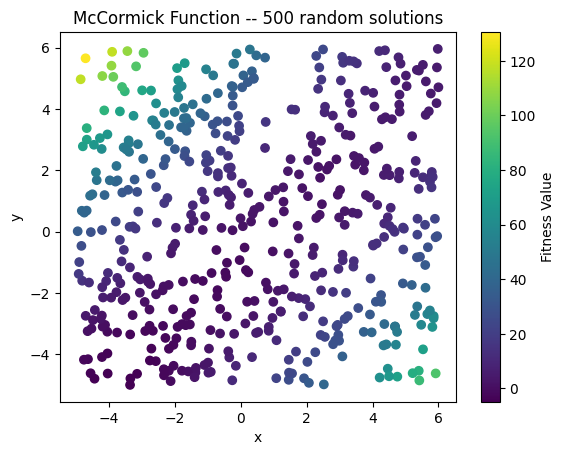

In [85]:
"""Task 2.1-- Generate 500 random soluitions."""
import numpy as numpy
from numpy import sin, random
from matplotlib import pyplot as plot

# create the McCormick function
def mccormick_function(x, y):
    return numpy.sin(x + y) + (x - y)** 2 - (1.5*x) + (2.5*y) + 1

x_vals, y_vals, function_results = [], [], []

for i in range (501):
    x = numpy.random.uniform(-5, 6)
    y = numpy.random.uniform(-5, 6)
    
    result = mccormick_function(x, y)
    x_vals.append(x)
    y_vals.append(y)
    function_results.append(result)
    

# plotting results onto a scatter plot 
plot.scatter(x_vals, y_vals, c=function_results)
plot.title('McCormick Function -- 500 random solutions')
plot.colorbar(label='Fitness Value')
plot.xlabel('x')
plot.ylabel('y')
plot.show()

In [86]:
# narrowing down the search area from 500 solutions to the TOP 100 solutions
indexes_sorted = numpy.argsort(function_results)[:100]

top_100_x =[]
top_100_y = []
top_100_results = []

for index in indexes_sorted:
    top_100_x.append(x_vals[index])
    top_100_y.append(y_vals[index])
    top_100_results.append(function_results[index])
    
# to narrow search area, need to get the highest and lowest bounds for X and Y
best_x = max(top_100_x)
worst_x = min(top_100_x)
best_y = max(top_100_y)
worst_y = min(top_100_y)

# print statement check
print (f"Best X value: {best_x}")
print (f"Worst X value: {worst_x}")
print (f"Best Y value: {best_y}")
print (f"Worst Y value: {worst_y}")

Best X value: 3.472820853690795
Worst X value: -4.760392934022459
Best Y value: 2.362260402204452
Worst Y value: -4.993587900555255


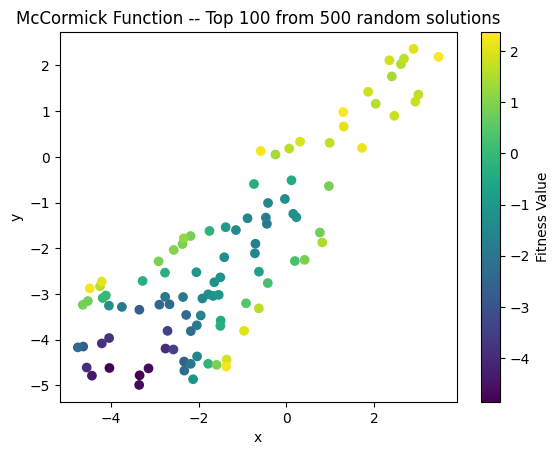

In [87]:
# plotting only the top 100 from the 500 random solutions 
plot.scatter(top_100_x, top_100_y, c=top_100_results)
plot.title('McCormick Function -- Top 100 from 500 random solutions')
plot.colorbar(label='Fitness Value')
plot.xlabel('x')
plot.ylabel('y')
plot.show()

### HillClimber algorithm & Additive Gaussian Mutator.

In [113]:
"""Task 2.2 -- Creating HillClimber and Gaussian Additive Mutation."""
import numpy as numpy
from numpy import sum

class GaussianMutation:
    def mutate (self, a):
        mutate_rate = 0.1
        mutation = numpy.random.normal(0, mutate_rate) 
        return a + mutation
    
mutation_operator = GaussianMutation().mutate

def hill_climbing_alg(no_iterations, best_x, worst_x, best_y, worst_y):
    fitness_vals = []
    
    px = numpy.random.uniform(worst_x, best_x)
    py = numpy.random.uniform(worst_y, worst_y)
    
    cx = mutation_operator(px)
    cy = mutation_operator(py)
    
    for i in range(no_iterations):
        if mccormick_function(cx, cy) < mccormick_function(px, py):
            px, py = cx, cy
            fit_val = mccormick_function(px, py)
        fitness_vals.append(fit_val)    
            
        cx = mutation_operator(px)
        cy = mutation_operator(py)
    return fitness_vals

In [114]:
fitness_vals = hill_climbing_alg(200, best_x, best_y, worst_x, worst_y)

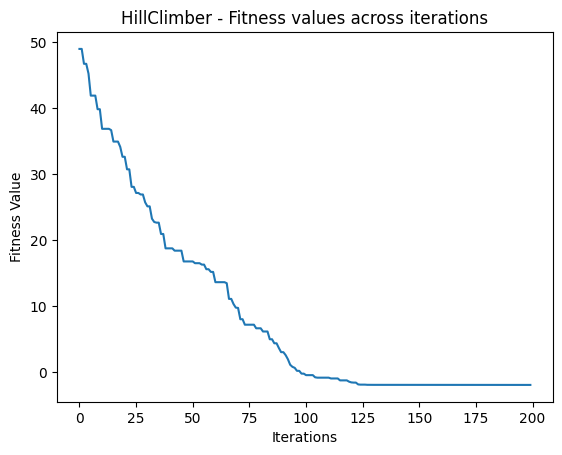

In [115]:
plot.plot(fitness_vals)
plot.title('HillClimber - Fitness values across iterations')
plot.xlabel('Iterations')
plot.ylabel('Fitness Value')
plot.show()

In [118]:
big_search_fitness_vals = hill_climbing_alg(200, -5, 6, -5, 6)

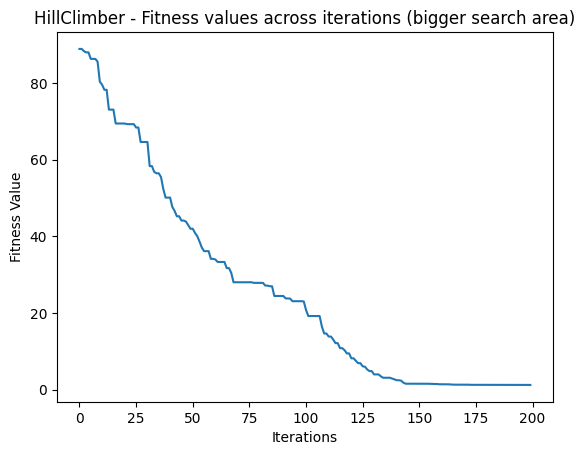

In [119]:
plot.plot(big_search_fitness_vals)
plot.title('HillClimber - Fitness values across iterations (bigger search area)')
plot.xlabel('Iterations')
plot.ylabel('Fitness Value')
plot.show()

### Population-based Evolutionary Algorithm.

In [60]:
def evolutionary_algorithm(no_iterations, pop_size, best_x, worst_x, best_y, worst_y):
    population = []
    array_fitness_vals = []
    best_x_values = []
    best_y_values = []
    
    for pop_index in range(pop_size):
        # creating the population given the bounds for x and y values from the top 100 and the population size
        px = numpy.random.uniform(worst_x, best_x)
        py = numpy.random.uniform(worst_y, best_y)
        parent_fitness_result = mccormick_function(px, py)
        population.append((px, py, parent_fitness_result))
        
    for num in range(no_iterations):
        for col in population:
            child_values = []
            
            cx = mutation_operator(col[0])
            cy = mutation_operator(col[1])
            child_fitness_result = mccormick_function(cx, cy)
            child_values.append((cx, cy, child_fitness_result))
            
            # combine the child values list with the populatin list
            compound = child_values + population
            
            # sort by ascending order of the fitness values
            sorted_compound = sorted(compound, key=lambda x: x[2])
            best_fit_value = sorted_compound[0][2]
            array_fitness_vals.append(best_fit_value)
            # because the combining made the list really big, reduce it down to the originally defined population size
            population = sorted_compound[0 :pop_size] 
                
        xv = population[0][0]
        yv = population[0][1]
        best_x_values.append(xv)
        best_y_values.append(yv)
    
    return array_fitness_vals, best_x_values, best_y_values

In [70]:
ev_x_vals, ev_y_vals, ev_fitness_vals = evolutionary_algorithm(20, 70, best_x, worst_x, best_y, worst_y)

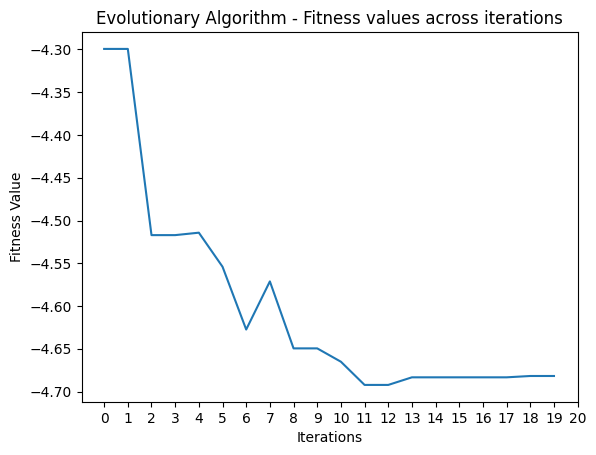

In [71]:
plot.plot(ev_fitness_vals)
plot.title('Evolutionary Algorithm - Fitness values across iterations')
plot.xlabel('Iterations')
plot.ylabel('Fitness Value')
plot.xticks(numpy.arange(0, 21, 1))
plot.show()

In [72]:
big_ev_x_vals, big_ev_y_vals, big_ev_fitness_vals = evolutionary_algorithm(20, 70, -5, 6, -5, 6)

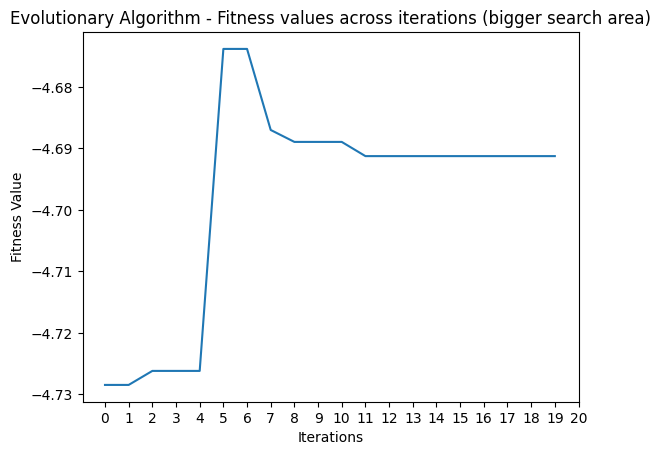

In [75]:
plot.plot(big_ev_fitness_vals)
plot.title('Evolutionary Algorithm - Fitness values across iterations (bigger search area)')
plot.xlabel('Iterations')
plot.ylabel('Fitness Value')
plot.xticks(numpy.arange(0, 21, 1))
plot.show()